<a href="https://colab.research.google.com/github/Dayinu/Projects/blob/Mushrooms-Binary-Classification/Mushrooms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


#1. Загрузка данных

In [ ]:
url = 'https://raw.githubusercontent.com/Dayinu/Projects/refs/heads/Mushrooms-Binary-Classification/mushrooms.csv'
df = pd.read_csv(url)

In [ ]:
df.shape

(8124, 23)

In [ ]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [ ]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing       

#2. EDA

In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.describe().round(2)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [ ]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


Распределение классов

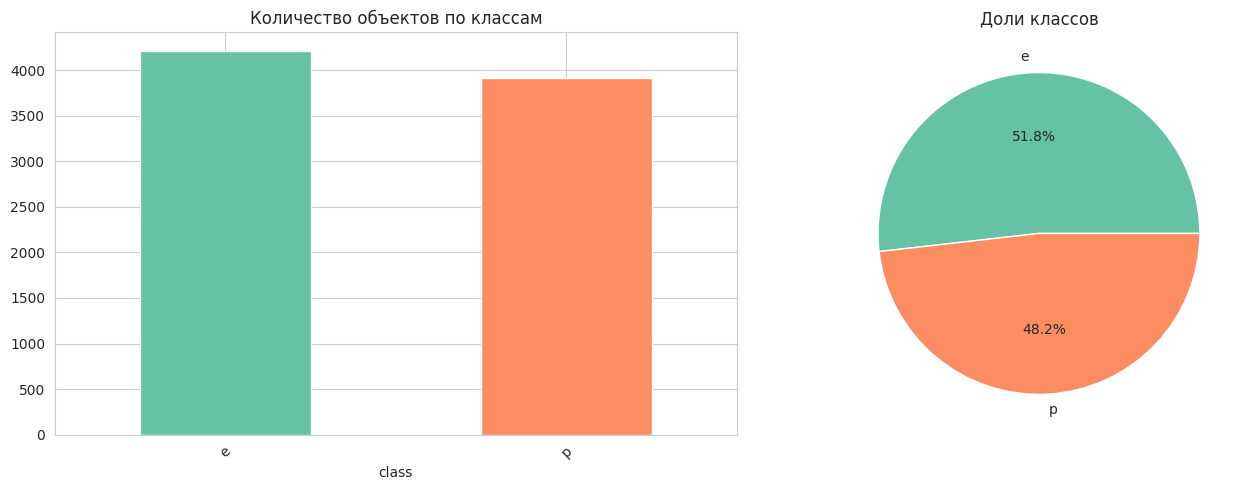

In [ ]:
target_col = 'class'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Распределения признаков

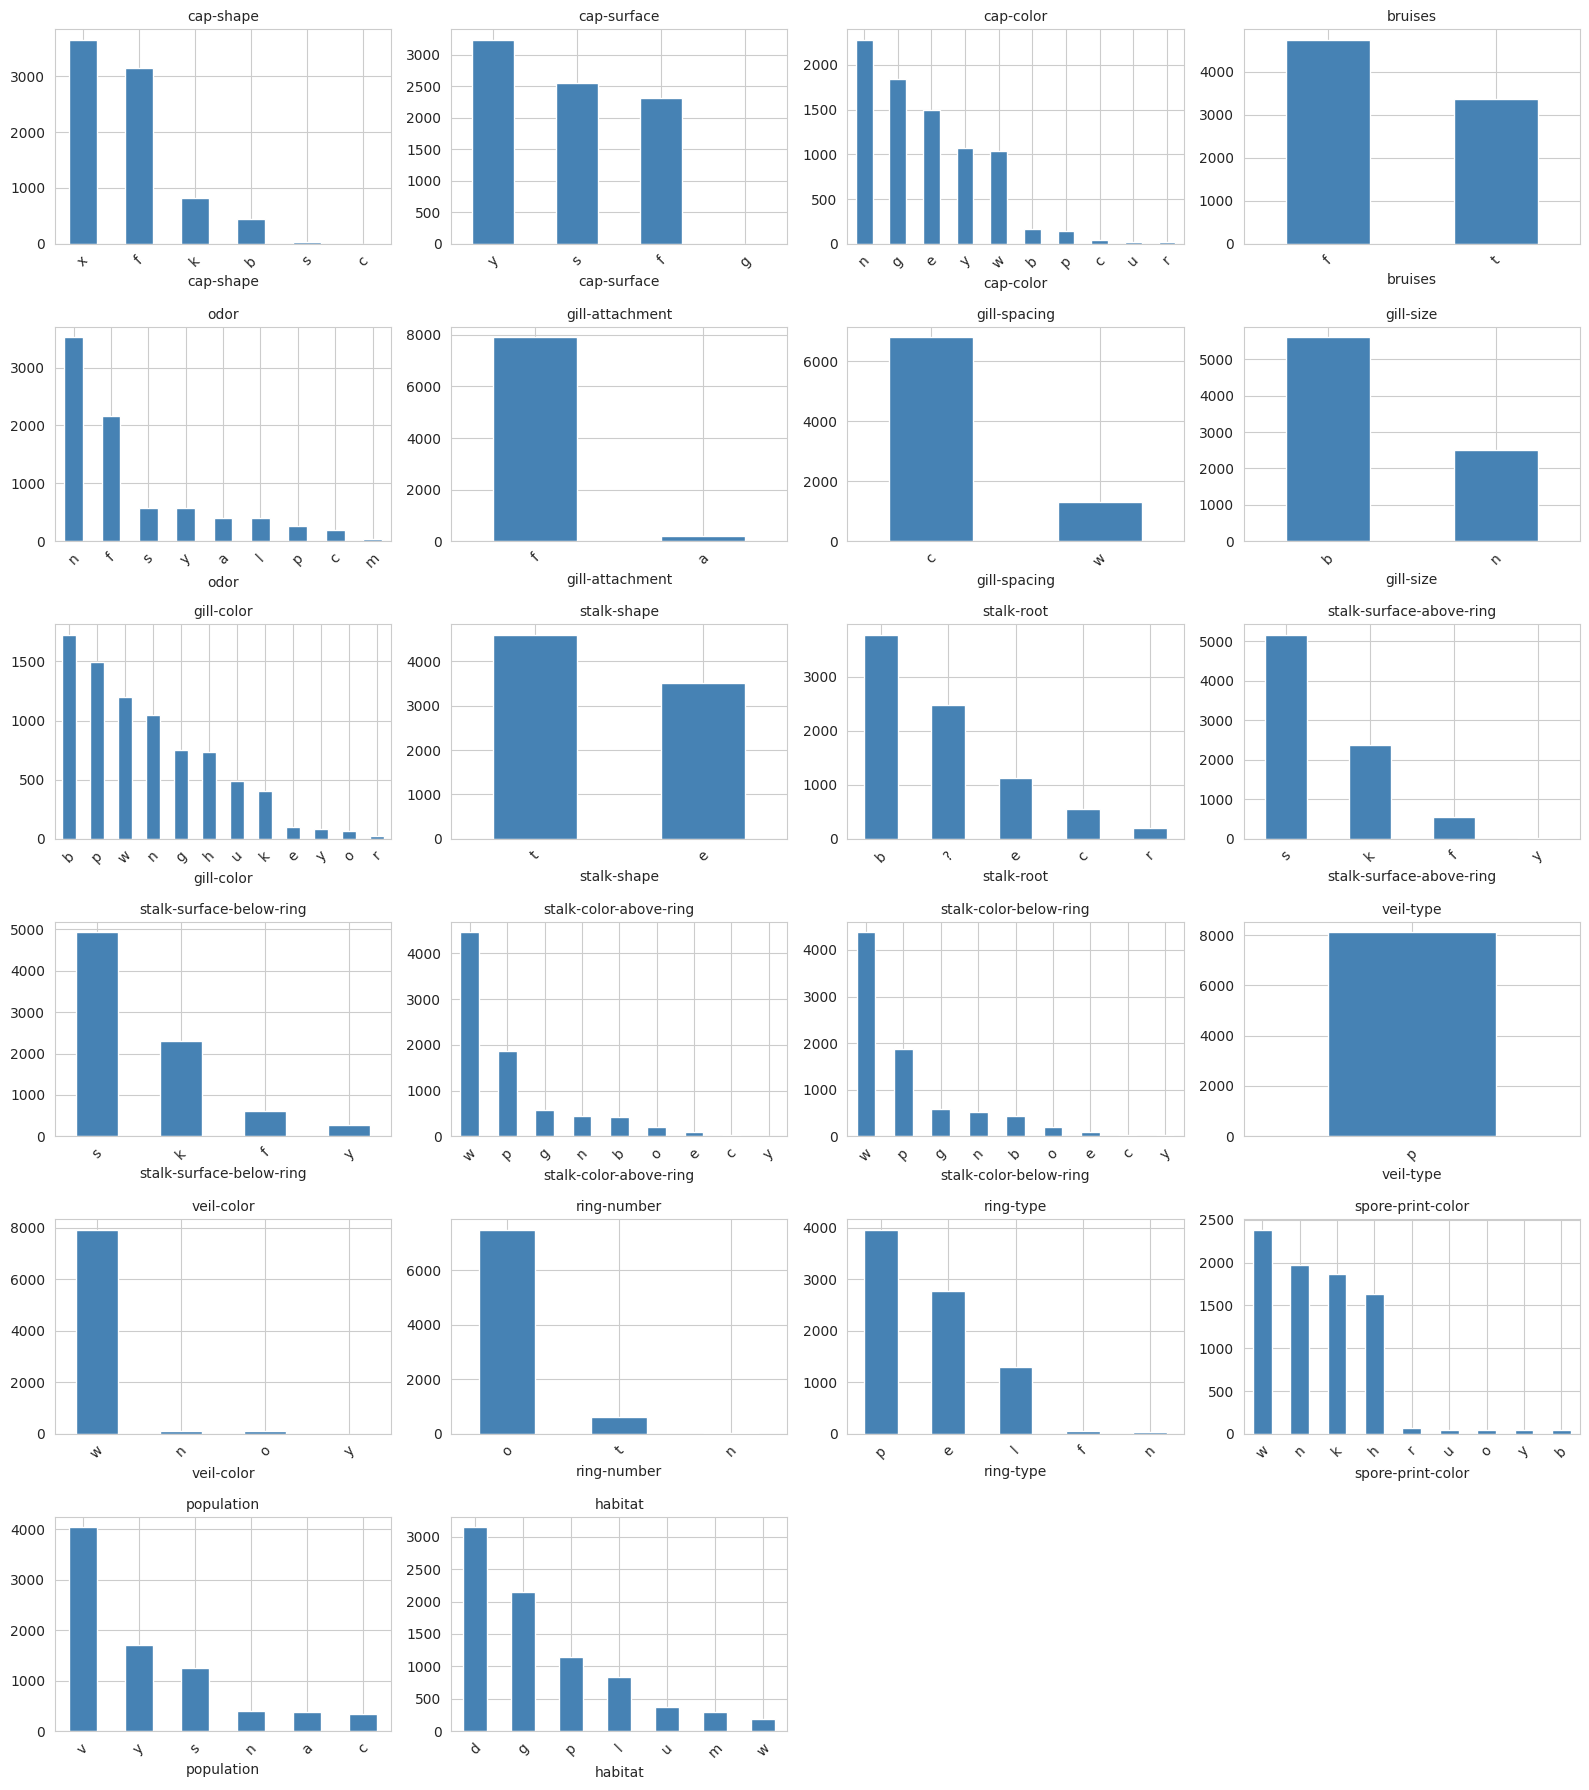

In [ ]:
categorical_cols = df.drop('class', axis=1).columns.tolist()

n_cols = len(categorical_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

veil-type имеет всего одно значение, значит от этого признака можно избавиться

Строим таблицы сопряженности

In [ ]:
for col in df.drop('class', axis=1).columns:
    cross = pd.crosstab(df[col], df['class'], normalize='index') * 100
    print(cross.round(2))
    print("-" * 50)

class           e       p
cap-shape                
b           89.38   10.62
c            0.00  100.00
f           50.63   49.37
k           27.54   72.46
s          100.00    0.00
x           53.28   46.72
--------------------------------------------------
class            e       p
cap-surface               
f            67.24   32.76
g             0.00  100.00
s            44.76   55.24
y            46.36   53.64
--------------------------------------------------
class           e      p
cap-color               
b           28.57  71.43
c           72.73  27.27
e           41.60  58.40
g           56.09  43.91
n           55.34  44.66
p           38.89  61.11
r          100.00   0.00
u          100.00   0.00
w           69.23  30.77
y           37.31  62.69
--------------------------------------------------
class        e      p
bruises              
f        30.67  69.33
t        81.52  18.48
--------------------------------------------------
class      e      p
odor              

stalk-shape, cap-surface, ring-number некоторые значения распределены между классами примено 50% на 50%, то есть не оказывают влияние на съедобность гриба, а есть наоборот некоторые значения на 100% соответсвующие одному из значений целевой перменной. Эти выводы частично подтверждают гипотезы 2 и 4

Строим визуализацию 6 призниаков, корреляция которых с целевой переменной наиболее заметна

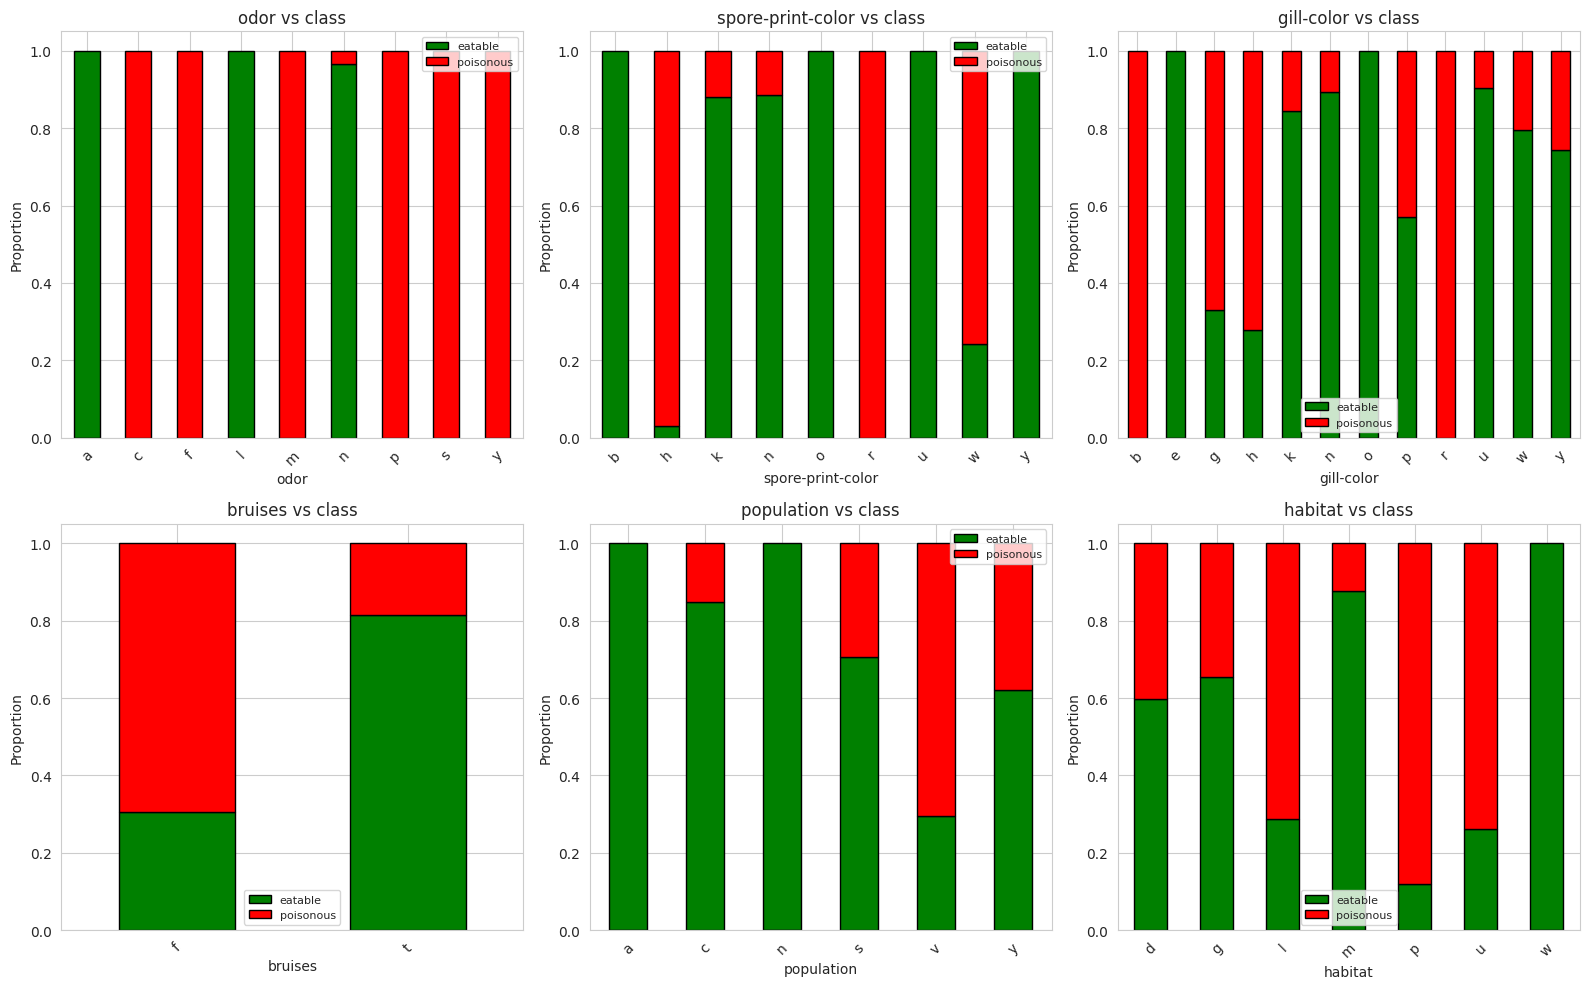

In [ ]:
top_features = ['odor', 'spore-print-color', 'gill-color', 'bruises', 'population', 'habitat']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    # Строим stacked bar chart
    pd.crosstab(df[col], df['class'], normalize='index').plot(
        kind='bar',
        ax=axes[idx],
        stacked=True,
        color=['green', 'red'],
        edgecolor='black'
    )
    axes[idx].set_title(f'{col} vs class', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(['eatable', 'poisonous'], fontsize=8)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Гипотеза №1: признак odor действительно почти идеально разделяет данные





Корреляционную матрицу, boxplot, pairplot не строим, потому что все признаки категориальные

#3. Подготовка данных


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.drop('veil-type', axis=1)

X = pd.get_dummies(df.drop('class', axis=1))

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

#4. Задача классификации

In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

X = pd.get_dummies(df.drop('class', axis=1))
y = LabelEncoder().fit_transform(df['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'LogReg (L2)': LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
    'LogReg (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000),
    'Ridge (L2)': RidgeClassifier(alpha=1.0),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted')
    })

pd.DataFrame(results).set_index('Model').round(4)

,Accuracy,F1 (weighted)
Model,,
LogReg (L2),1.0,1.0
LogReg (L1),1.0,1.0
Ridge (L2),1.0,1.0
Decision Tree,1.0,1.0


Гипотеза №3 подтвердилась, accuracy и f1 приняли значение 1.0

Теперь сделаем масштабирование для проверки гипотезы 5

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg_scaled = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
logreg_scaled.fit(X_train_scaled, y_train)
y_proba_scaled = logreg_scaled.predict_proba(X_test_scaled)[:, 1]
auc_scaled = roc_auc_score(y_test, y_proba_scaled)

print("ROC-AUC с масштабированием:", auc_scaled)

ROC-AUC с масштабированием: 1.0


Гипотеза №5 подтверждается ROC AUC действительно не меняется и масштабировать категориальные данные не имеет смысла

# 5. Метрики

In [ ]:
summary = []
for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        log_loss_val = log_loss(y_test, y_proba)
    else:
        roc_auc = '-'
        log_loss_val = '-'

    summary.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
        'Log-Loss': log_loss_val
    })

pd.DataFrame(summary).set_index('Model').round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,Log-Loss
Model,,,,,,
LogReg (L2),1.0,1.0,1.0,1.0,1.0,0.005946
LogReg (L1),1.0,1.0,1.0,1.0,1.0,0.002684
Ridge (L2),1.0,1.0,1.0,1.0,-,-
Decision Tree,1.0,1.0,1.0,1.0,1.0,0.0


Функция потерь на L1 двольно мала и меньше чем на L2, что также говорит о корректности гипотезы 2

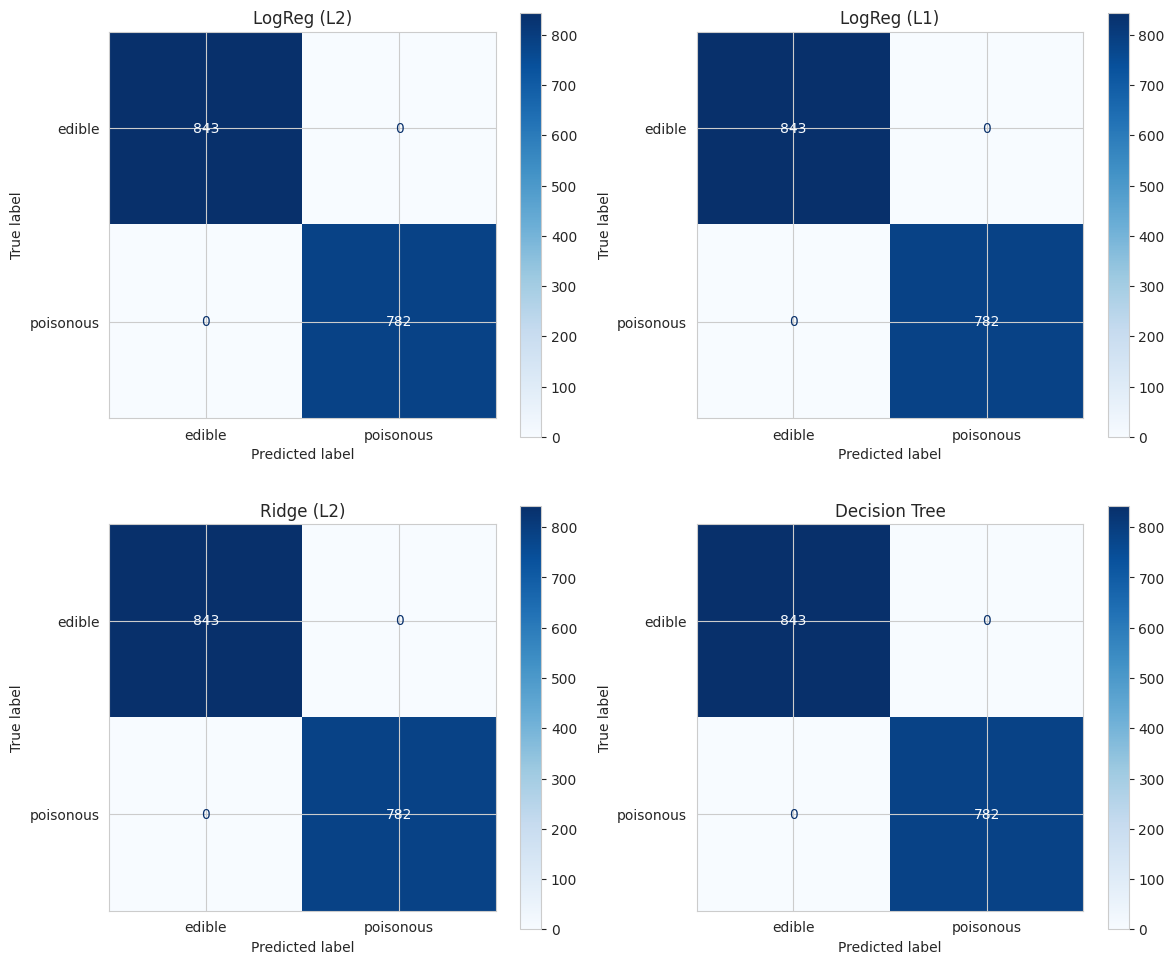

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        ax=axes[idx],
        cmap='Blues',
        display_labels=['edible', 'poisonous']
    )
    axes[idx].set_title(f'{name}')

plt.tight_layout()
plt.show()

Гипотеза №4 подтверждается: значение ошибок зачастую ноль

# 6. Кроссвалидация

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier

models_cv = {
    'LogReg (L2)': LogisticRegression(penalty='l2', C=1.0, max_iter=1000),
    'LogReg (L1)': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000),
    'Ridge (L2)': RidgeClassifier(alpha=1.0),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted')
    cv_results.append({
        'Model': name,
        'CV F1 mean': scores.mean(),
        'CV F1 std': scores.std()
    })

pd.DataFrame(cv_results).set_index('Model').round(4)

,CV F1 mean,CV F1 std
Model,,
LogReg (L2),1.0000,0.0000
LogReg (L1),1.0000,0.0000
Ridge (L2),0.9995,0.0006
Decision Tree,1.0000,0.0000


# 7. GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
)
grid_search.fit(X_train, y_train)

grid_search.best_params_, grid_search.best_score_.round(4)

({'criterion': 'gini',
  'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(1.0))

#8. Отбор признаков

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

selector = SelectKBest(f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

logreg_selected = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
logreg_selected.fit(X_train_selected, y_train)
y_pred_selected = logreg_selected.predict(X_test_selected)

print("Результаты после отбора 10 признаков: ")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print("F1 (weighted):", f1_score(y_test, y_pred_selected, average='weighted'))

selected_indices = selector.get_support(indices=True)
selected_features = X_train.columns[selected_indices]
print("\nОтобранные признаки:")
print(selected_features.tolist())

Результаты после отбора 10 признаков: 
Accuracy: 0.9735384615384616
F1 (weighted): 0.9735439782771127

Отобранные признаки:
['bruises_f', 'bruises_t', 'odor_f', 'odor_n', 'gill-size_b', 'gill-size_n', 'gill-color_b', 'stalk-surface-above-ring_k', 'stalk-surface-below-ring_k', 'ring-type_p']


Гипотеза 6 подтверждается: Accuracy и F1 после отбора 10 признаков с помощью selectKBest показывают значения, близкие к 1